# Import all important libraries needed

In [1]:
import pandas as pd                 # For data manipulation
import numpy as np                  # For numerical operations
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For advanced visualizations
import datetime                     # For date/time manipulation

# Preparing our data for analysis

In [2]:
# Load Divvy_trips_2019_Q1.csv
q1_2019 = pd.read_csv('datasets/Divvy_Trips_2019_Q1.csv') 

# Load Divvy_Trips_2020_Q1.csv
q1_2020 = pd.read_csv('datasets/Divvy_Trips_2020_Q1.csv')

In [3]:
# Display the first few rows of q1_2019
q1_2019.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0


In [4]:
# Display the first few rows of q1_2020
q1_2020.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [5]:
# Standardizing column names of q1_2019 to match the structure of q1_2020 
q1_2019.rename(columns={
    'trip_id': 'ride_id',
    'bikeid': 'rideable_type',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
}, inplace=True)

In [6]:
# Check data structure
q1_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             365069 non-null  int64  
 1   started_at          365069 non-null  object 
 2   ended_at            365069 non-null  object 
 3   rideable_type       365069 non-null  int64  
 4   tripduration        365069 non-null  object 
 5   start_station_id    365069 non-null  int64  
 6   start_station_name  365069 non-null  object 
 7   end_station_id      365069 non-null  int64  
 8   end_station_name    365069 non-null  object 
 9   member_casual       365069 non-null  object 
 10  gender              345358 non-null  object 
 11  birthyear           347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB


In [7]:
# Check data structure
q1_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 42.3+ MB


In [8]:
# Convert ride_id and rideable_type to string
q1_2019['ride_id'] = q1_2019['ride_id'].astype(str)
q1_2019['rideable_type'] = q1_2019['rideable_type'].astype(str)

In [9]:
# Combine both datasets and name the new table: all_trips
all_trips = pd.concat([q1_2019, q1_2020], ignore_index=True)

In [10]:
# Drop irrelevant columns
columns_to_drop = ['start_lat', 'start_lng', 'end_lat', 'end_lng', 'birthyear', 'gender', 'tripduration']
all_trips = all_trips.drop(columns=[col for col in columns_to_drop if col in all_trips.columns])

In [11]:
# Display first couple of rows of the new all_trips table
all_trips.head()

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,Subscriber
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),Subscriber
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),Subscriber
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,Subscriber
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,Subscriber


In [12]:
# Display info
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             791956 non-null  object 
 1   started_at          791956 non-null  object 
 2   ended_at            791956 non-null  object 
 3   rideable_type       791956 non-null  object 
 4   start_station_id    791956 non-null  int64  
 5   start_station_name  791956 non-null  object 
 6   end_station_id      791955 non-null  float64
 7   end_station_name    791955 non-null  object 
 8   member_casual       791956 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 54.4+ MB


# Processing our data for analysis

In [13]:
# Drop any null values from the table
all_trips.dropna(inplace=True)

In [14]:
# Check if all null rows have been removed
all_trips.isnull().sum()

ride_id               0
started_at            0
ended_at              0
rideable_type         0
start_station_id      0
start_station_name    0
end_station_id        0
end_station_name      0
member_casual         0
dtype: int64

In [15]:
# Make sure both started_at and ended_at are datetime 
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

print(all_trips.dtypes)

ride_id                       object
started_at            datetime64[ns]
ended_at              datetime64[ns]
rideable_type                 object
start_station_id               int64
start_station_name            object
end_station_id               float64
end_station_name              object
member_casual                 object
dtype: object


In [16]:
# Create a day_of_week column to our table
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()

In [17]:
# Create a ride_length column to our table
# ride_length will be measured in seconds
all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds()

In [18]:
# Display new table with new columns
all_trips.head()

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,day_of_week,ride_length
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,Subscriber,Tuesday,390.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),Subscriber,Tuesday,441.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),Subscriber,Tuesday,829.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,Subscriber,Tuesday,1783.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,Subscriber,Tuesday,364.0


In [19]:
# Display last few rows of all_trips
all_trips.tail()

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,day_of_week,ride_length
791951,ADDAA33CEBCAE733,2020-03-10 10:40:06,2020-03-10 10:40:07,docked_bike,675,HQ QR,675.0,HQ QR,casual,Tuesday,1.0
791952,82B10FA3994BC66A,2020-03-07 15:25:55,2020-03-07 16:14:03,docked_bike,161,Rush St & Superior St,240.0,Sheridan Rd & Irving Park Rd,member,Saturday,2888.0
791953,AA0D5AAA0B59C8AA,2020-03-01 13:12:38,2020-03-01 13:38:29,docked_bike,141,Clark St & Lincoln Ave,210.0,Ashland Ave & Division St,casual,Sunday,1551.0
791954,3296360A7BC20FB8,2020-03-07 18:02:45,2020-03-07 18:13:18,docked_bike,672,Franklin St & Illinois St,264.0,Stetson Ave & South Water St,member,Saturday,633.0
791955,064EC7698E4FF9B3,2020-03-08 13:03:57,2020-03-08 13:32:27,docked_bike,110,Dearborn St & Erie St,85.0,Michigan Ave & Oak St,casual,Sunday,1710.0


In [20]:
# Replace Subscriber with member and Customer with casual
all_trips['member_casual'] = all_trips['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

In [21]:
# Check to see if the proper naming conventions were applied
all_trips['member_casual'].value_counts()

member_casual
member    720313
casual     71642
Name: count, dtype: int64

In [22]:
# Find negative values in ride_length column
negative_values = all_trips[all_trips['ride_length'] < 0]
negative_values

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,day_of_week,ride_length
520401,9461DFF13D8BA8AD,2020-02-28 10:09:43,2020-02-28 10:09:42,docked_bike,675,HQ QR,675.0,HQ QR,casual,Friday,-1.0
648666,794264334D168D05,2020-03-18 11:43:09,2020-03-18 11:42:58,docked_bike,675,HQ QR,675.0,HQ QR,casual,Wednesday,-11.0
651962,3CC0D87545CE223B,2020-03-19 09:43:05,2020-03-19 09:42:51,docked_bike,675,HQ QR,675.0,HQ QR,casual,Thursday,-14.0
652289,32CAF6E2E7AB67CE,2020-03-12 10:00:46,2020-03-12 10:00:36,docked_bike,675,HQ QR,675.0,HQ QR,casual,Thursday,-10.0
653844,13BCB74BAFDADB21,2020-03-27 14:59:51,2020-03-27 14:58:18,docked_bike,675,HQ QR,675.0,HQ QR,casual,Friday,-93.0
...,...,...,...,...,...,...,...,...,...,...,...
786502,C2F71E40D52A0660,2020-03-18 15:12:18,2020-03-18 15:12:04,docked_bike,675,HQ QR,675.0,HQ QR,casual,Wednesday,-14.0
786686,14AF5815838B9F2C,2020-03-13 08:38:14,2020-03-13 08:38:03,docked_bike,675,HQ QR,675.0,HQ QR,casual,Friday,-11.0
788670,D94EF149247F3880,2020-03-19 10:24:16,2020-03-19 10:24:05,docked_bike,675,HQ QR,675.0,HQ QR,casual,Thursday,-11.0
788945,323CAC41316F59B2,2020-03-13 08:51:45,2020-03-13 08:51:34,docked_bike,675,HQ QR,675.0,HQ QR,casual,Friday,-11.0


In [23]:
# Remove any rows with negative ride_length values or where the start station is HQ QR
# Create a new table called all_trips_v2
# This table will be used for further analysis
all_trips_v2 = all_trips[~((all_trips['start_station_name'] == 'HQ QR') | (all_trips['ride_length'] < 0))]

In [24]:
all_trips_v2.head()

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,day_of_week,ride_length
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,member,Tuesday,390.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),member,Tuesday,441.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),member,Tuesday,829.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,member,Tuesday,1783.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,member,Tuesday,364.0


In [25]:
all_trips_v2.tail()

,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,day_of_week,ride_length
791949,005D3BC2A3B33DDA,2020-03-12 07:32:25,2020-03-12 07:38:44,docked_bike,91,Clinton St & Washington Blvd,47.0,State St & Kinzie St,member,Thursday,379.0
791952,82B10FA3994BC66A,2020-03-07 15:25:55,2020-03-07 16:14:03,docked_bike,161,Rush St & Superior St,240.0,Sheridan Rd & Irving Park Rd,member,Saturday,2888.0
791953,AA0D5AAA0B59C8AA,2020-03-01 13:12:38,2020-03-01 13:38:29,docked_bike,141,Clark St & Lincoln Ave,210.0,Ashland Ave & Division St,casual,Sunday,1551.0
791954,3296360A7BC20FB8,2020-03-07 18:02:45,2020-03-07 18:13:18,docked_bike,672,Franklin St & Illinois St,264.0,Stetson Ave & South Water St,member,Saturday,633.0
791955,064EC7698E4FF9B3,2020-03-08 13:03:57,2020-03-08 13:32:27,docked_bike,110,Dearborn St & Erie St,85.0,Michigan Ave & Oak St,casual,Sunday,1710.0


# Conduct Descriptive Analysis 

In [ ]:
# Check the mean, median, mode, max, and min of ride_length
print("Mean:", all_trips_v2['ride_length'].mean())
print("Median:", all_trips_v2['ride_length'].median())
print("Max:", all_trips_v2['ride_length'].max())
print("Min:", all_trips_v2['ride_length'].min())

Mean: 1189.4586882080314
Median: 539.0
Max: 10632022.0
Min: 1.0


In [ ]:
# Mean between members and casual users
all_trips_v2.groupby('member_casual')['ride_length'].mean()

member_casual
casual    5372.783874
member     795.252339
Name: ride_length, dtype: float64

In [ ]:
# Median between members and casual users
all_trips_v2.groupby('member_casual')['ride_length'].median()

member_casual
casual    1393.0
member     508.0
Name: ride_length, dtype: float64

In [ ]:
# Max between members and casual users
all_trips_v2.groupby('member_casual')['ride_length'].max()

member_casual
casual    10632022.0
member     6096428.0
Name: ride_length, dtype: float64

In [ ]:
# Min between members and casual users
all_trips_v2.groupby('member_casual')['ride_length'].min()

member_casual
casual    2.0
member    1.0
Name: ride_length, dtype: float64

In [ ]:
# Average ride time by day and member Type
weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'], categories=weekday_order, ordered=True)

avg_ride_time = all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean().reset_index()
avg_ride_time

C:\Users\zuzu\AppData\Local\Temp\ipykernel_9424\3554658715.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'], categories=weekday_order, ordered=True)
C:\Users\zuzu\AppData\Local\Temp\ipykernel_9424\3554658715.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_ride_time = all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean().reset_index()


,member_casual,day_of_week,ride_length
0,casual,Sunday,5061.304364
1,casual,Monday,4752.050438
2,casual,Tuesday,4561.803857
3,casual,Wednesday,4480.372432
4,casual,Thursday,8451.666853
5,casual,Friday,6090.737302
6,casual,Saturday,4950.770801
7,member,Sunday,972.938336
8,member,Monday,822.311202
9,member,Tuesday,769.441629


In [ ]:
# Analyze Ridership by Type and Weekday
all_trips_v2['weekday'] = all_trips_v2['started_at'].dt.day_name()
all_trips_v2['weekday'] = pd.Categorical(all_trips_v2['weekday'], categories=weekday_order, ordered=True)

summary_df = all_trips_v2.groupby(['member_casual', 'weekday']).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length', 'mean')
).reset_index()

summary_df = summary_df.sort_values(by=['member_casual', 'weekday'])
summary_df.head()

C:\Users\zuzu\AppData\Local\Temp\ipykernel_9424\1597683098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_trips_v2['weekday'] = all_trips_v2['started_at'].dt.day_name()
C:\Users\zuzu\AppData\Local\Temp\ipykernel_9424\1597683098.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_trips_v2['weekday'] = pd.Categorical(all_trips_v2['weekday'], categories=weekday_order, ordered=True)
C:\Users\zuzu\AppData\Local\Temp\ipykernel_9424\1597683098.py:8: FutureWarning: The default of observed=False is depr

,member_casual,weekday,number_of_rides,average_duration
0,casual,Sunday,18652,5061.304364
1,casual,Monday,5591,4752.050438
2,casual,Tuesday,7311,4561.803857
3,casual,Wednesday,7690,4480.372432
4,casual,Thursday,7147,8451.666853


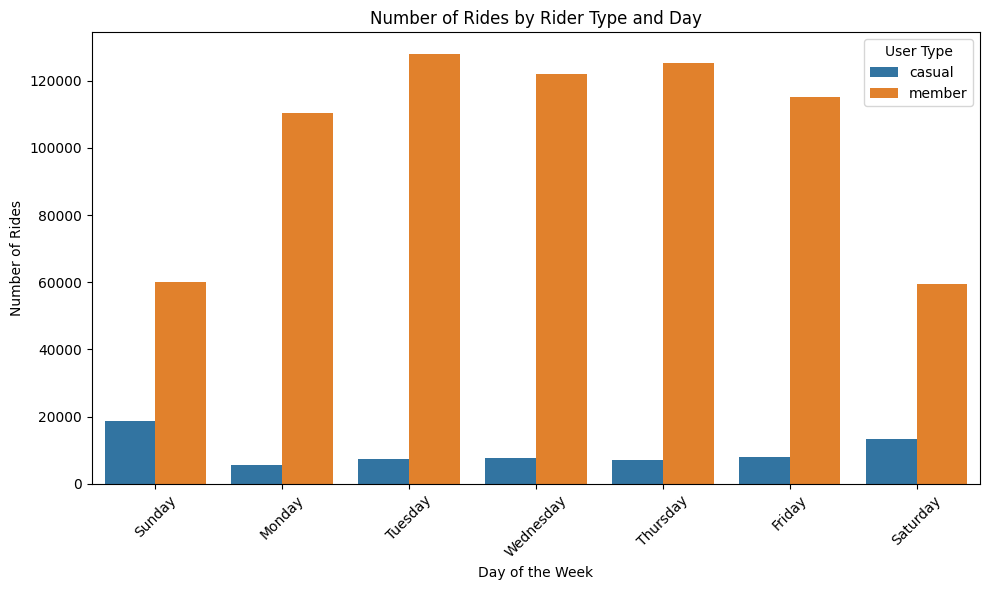

In [ ]:
# Visualization – Number of Rides by Rider Type and Day
plt.figure(figsize=(10,6))
sns.barplot(
    data=summary_df,
    x='weekday', y='number_of_rides', hue='member_casual'
)
plt.title('Number of Rides by Rider Type and Day')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

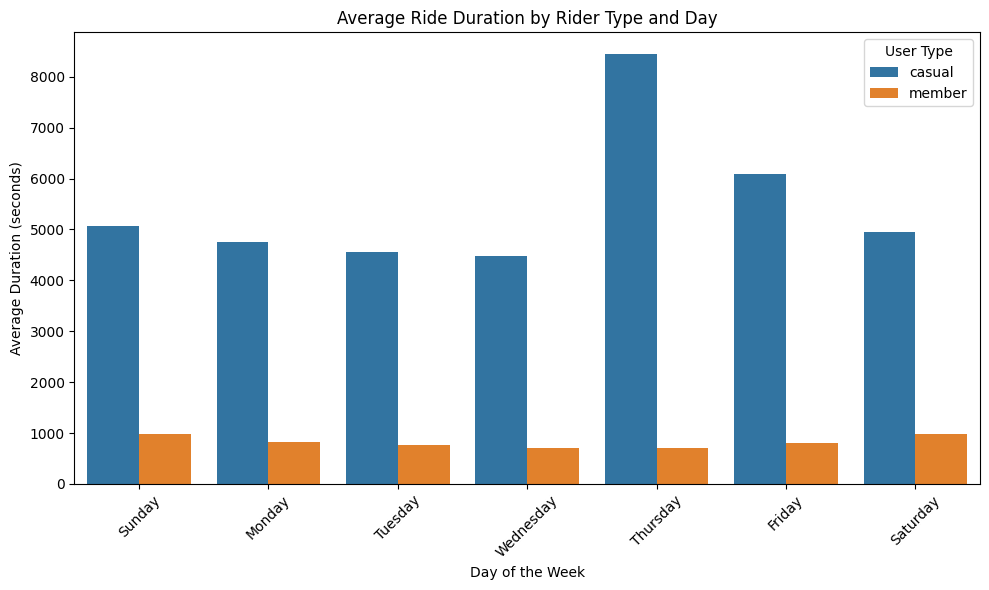

In [ ]:
# Visualization – Average Ride Duration by Rider Type and Day
plt.figure(figsize=(10,6))
sns.barplot(
    data=summary_df,
    x='weekday', y='average_duration', hue='member_casual'
)
plt.title('Average Ride Duration by Rider Type and Day')
plt.xlabel('Day of the Week')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.tight_layout()
plt.show()